# Holiday-Cheer - a quantitative teardown 🔬
### Holiday-from-gaps calendar · HAC inference · Wilson win-rates · bootstrap decay test

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Faded since 1990?: Confirmed](https://img.shields.io/badge/Faded_since_1990%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) - *same seven beats, every claim now carrying its standard error.* We separate the three facts about the pre-holiday effect: it was **real and large** (long sample), it **faded after 1990** (tested), and it is **un-tradable** (capacity).

> ⚠️ **Not investment advice.** ^GSPC daily **price-only** (no dividends - stated) back to 1950 for magnitude + decay; SPY **total-return** (1993+) for the fair compare. The holiday calendar is derived offline from the trading index. Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (holiday_cheer/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from holiday_cheer import data, strategy

AS_OF = "2026-06-12"
# Long price-only tape for the magnitude + decay story; total-return SPY for the fair compare.
g = data.load_real("^GSPC", start="1950-01-01", mode="split_only").loc[:AS_OF]
gclose = g["close"]; gpre = data.pre_holiday_mask(gclose.index)
spy = data.load_real("SPY", mode="total_return").loc[:AS_OF]
sclose = spy["close"]; spre = data.pre_holiday_mask(sclose.index)
ge = strategy.effect_stats(gclose, gpre)
se = strategy.effect_stats(sclose, spre)
print(f"^GSPC price-only: {len(gclose):,} rows  {gclose.index[0].date()} -> {gclose.index[-1].date()}  fp={data.fingerprint(g)}")
print(f"  pre-holiday {ge['mu_pre']*1e4:.2f} bps vs rest {ge['mu_rest']*1e4:.2f} bps  ratio {ge['ratio']:.1f}x  HAC t(gap)={ge['t_gap']:.2f}")
print(f"SPY total-return: {len(sclose):,} rows  fp={data.fingerprint(spy)}  pre {se['mu_pre']*1e4:.2f} vs {se['mu_rest']*1e4:.2f} bps  t(gap)={se['t_gap']:.2f}")


^GSPC price-only: 19,233 rows  1950-01-03 -> 2026-06-12  fp=0198a54a32c0
  pre-holiday 18.89 bps vs rest 3.09 bps  ratio 6.1x  HAC t(gap)=5.05
SPY total-return: 8,400 rows  fp=eb1569cc9e97  pre 9.60 vs 4.58 bps  t(gap)=0.98


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `MIXED` | Real on 1950+ (gap **+15.8 bps**, **6.1x**, HAC *t* = **5.05**), but carried by the early sample: pre-1990 *t* = **7.25**, post-1990 *t* = **1.96**, modern SPY-TR *t* = **0.98**. Real, then faded. |
| **Tradability** | `MIRAGE` | ~9 days/yr; pre-holiday-only book **1.5%/yr** vs **8.3%** B&H, in market 3.6% of the time. |
| **Faded since 1990?** | `CONFIRMED` | decay **20.1 bps**, P(decay>0) = **0.999**, 95% CI [6.8, 32.8] bps. |

> 💡 **In plain words:** a genuine anomaly that paid handsomely on the few days it touched - and then mostly arbitraged itself away once it was published.

## 1 · The claim, steelmanned

- **H₁ (existence):** pre-holiday days earn more than other days.
- **H₂ (decay):** the effect is smaller after Ariel (1990) than before.
- **H₃ (tradability):** a pre-holiday-only book competes with buy-and-hold.

We find H₁ true on the long tape, H₂ true and significant, and H₃ false - the textbook 'real-but-untradable, and fading' anomaly profile.

## 2 · So what?

If H₃ held, a calendar lookup would beat indexing. It doesn't - and the *why* (too few days, plus post-publication decay) is the lesson about calendar anomalies.

## 3 · How we'd know - the protocol

Derive holidays from index gaps · pre-holiday vs rest with **HAC** *t* and **Wilson** win-rate intervals · pre-holiday-only book vs B&H (capacity) · **pre/post-1990** split with a **circular-block-bootstrap** test of the gap *difference*.

## 4 · The teardown

The effect, both tapes (price-only 1950+ and total-return 1993+):

In [2]:
tbl = pd.DataFrame({
  'pre-holiday bps': [ge['mu_pre']*1e4, se['mu_pre']*1e4],
  'rest bps':        [ge['mu_rest']*1e4, se['mu_rest']*1e4],
  'ratio':           [ge['ratio'], se['ratio']],
  'gap bps':         [ge['gap']*1e4, se['gap']*1e4],
  'HAC t(gap)':      [ge['t_gap'], se['t_gap']],
  'win% pre':        [ge['win_pre']*100, se['win_pre']*100],
  'win% rest':       [ge['win_rest']*100, se['win_rest']*100],
}, index=['^GSPC price-only 1950+', 'SPY total-return 1993+'])
tbl.round(2)

,pre-holiday bps,rest bps,ratio,gap bps,HAC t(gap),win% pre,win% rest
^GSPC price-only 1950+,18.890,3.090,6.110,15.800,5.050,64.250,52.740
SPY total-return 1993+,9.600,4.580,2.090,5.020,0.980,57.140,54.000


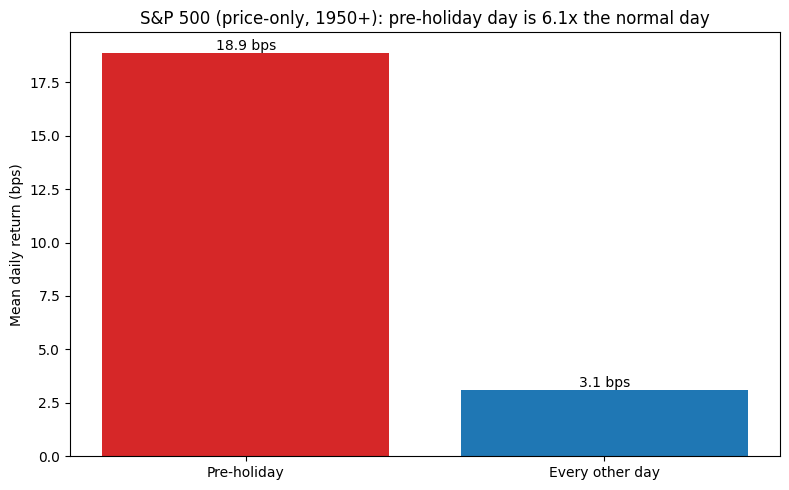

gap = +15.80 bps   HAC t(gap) = +5.05   win-rate 64% vs 53%


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Pre-holiday', 'Every other day']
vals = [ge['mu_pre']*1e4, ge['mu_rest']*1e4]
bars = ax.bar(labels, vals, color=['C3', 'C0'])
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.1f} bps', ha='center', va='bottom')
ax.set_ylabel('Mean daily return (bps)')
ax.set_title(f"S&P 500 (price-only, 1950+): pre-holiday day is {ge['ratio']:.1f}x the normal day")
plt.tight_layout(); plt.show()
print(f"gap = {ge['gap']*1e4:+.2f} bps   HAC t(gap) = {ge['t_gap']:+.2f}   win-rate {ge['win_pre']*100:.0f}% vs {ge['win_rest']*100:.0f}%")

> 💡 **In plain words:** on the long tape the pre-holiday day is unmistakably special; on the modern total-return tape alone the gap is half as big and the *t* (0.98) can't certify it - which is the first hint the effect is mostly an old-sample phenomenon.

**Wilson win-rate intervals** - the up-rate on pre-holiday vs other days (do the CIs overlap?):

In [4]:
wp, wr = ge['wilson_pre'], ge['wilson_rest']
print(f"^GSPC pre-holiday up-rate {ge['win_pre']*100:.1f}% [{wp[0]*100:.1f}, {wp[1]*100:.1f}]")
print(f"^GSPC other-day  up-rate {ge['win_rest']*100:.1f}% [{wr[0]*100:.1f}, {wr[1]*100:.1f}]")
print('=> non-overlapping intervals: the pre-holiday up-rate is reliably higher (long sample).')

^GSPC pre-holiday up-rate 64.2% [60.6, 67.7]
^GSPC other-day  up-rate 52.7% [52.0, 53.5]
=> non-overlapping intervals: the pre-holiday up-rate is reliably higher (long sample).


**Capacity** - the pre-holiday-only book vs buy-and-hold:

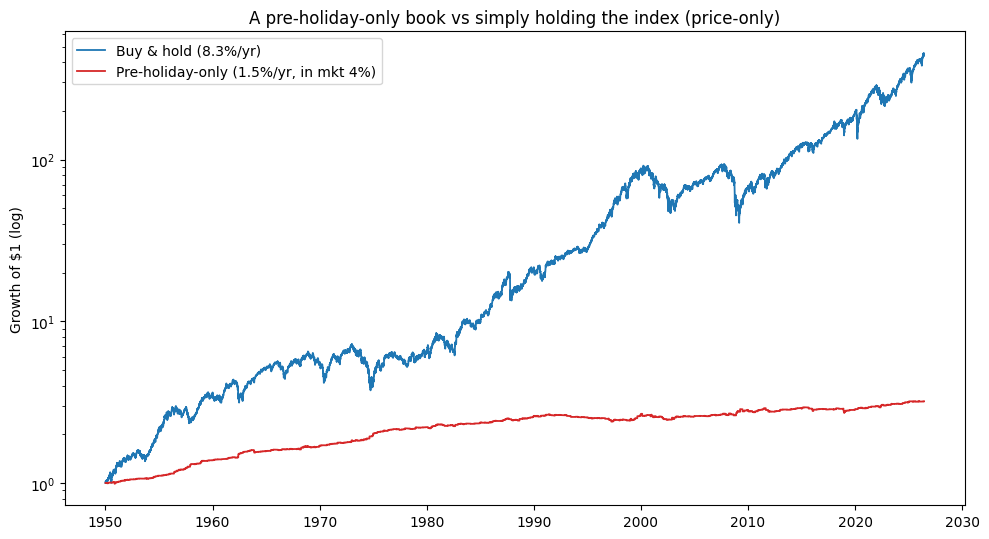

pre-only days invested = 702 (3.6% of tape); per-invested-day Sharpe = 3.57, but whole-tape CAGR 1.54% vs B&H 8.32%


In [5]:
book = strategy.pre_holiday_only(gclose, gpre, cost_bps=1.0)
bh = strategy.buy_and_hold(gclose)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(bh['equity'], label=f"Buy & hold ({bh['cagr']*100:.1f}%/yr)", lw=1.3)
ax.plot(book['equity'], label=f"Pre-holiday-only ({book['cagr']*100:.1f}%/yr, in mkt {book['time_in_market']*100:.0f}%)", lw=1.3, color='C3')
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)')
ax.set_title('A pre-holiday-only book vs simply holding the index (price-only)'); ax.legend()
plt.tight_layout(); plt.show()
print(f"pre-only days invested = {book['days_invested']} ({book['time_in_market']*100:.1f}% of tape); "
      f"per-invested-day Sharpe = {book['sharpe_invested']:.2f}, but whole-tape CAGR {book['cagr']*100:.2f}% vs B&H {bh['cagr']*100:.2f}%")

> 💡 **In plain words:** per *invested* day the book's Sharpe is huge (~3.6), but it's in cash 96% of the time, so its whole-tape return is a small fraction of the index. Capacity, not cost, is what kills it.

**The decay** - pre/post-1990 with a bootstrap test of the *difference*:

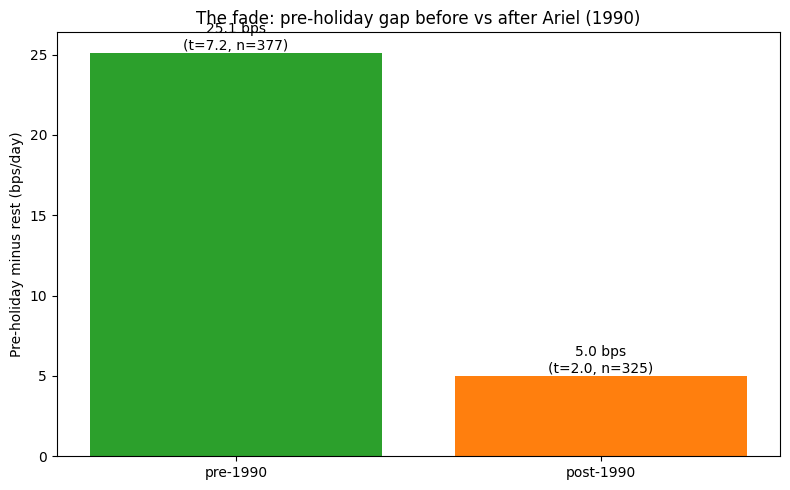

decay = 20.11 bps   P(decay>0) = 0.999   95% CI [6.8, 32.8] bps


In [6]:
c = strategy.subperiod_contrast(gclose, gpre, split_date='1990-01-01')
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['pre-1990', 'post-1990']
vals = [c['gap_early']*1e4, c['gap_late']*1e4]
bars = ax.bar(labels, vals, color=['C2', 'C1'])
for b, v, t, n in zip(bars, vals, [c['t_early'], c['t_late']], [c['n_pre_early'], c['n_pre_late']]):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.1f} bps\n(t={t:.1f}, n={n})', ha='center', va='bottom')
ax.axhline(0, color='k', lw=.6)
ax.set_ylabel('Pre-holiday minus rest (bps/day)')
ax.set_title('The fade: pre-holiday gap before vs after Ariel (1990)')
plt.tight_layout(); plt.show()
print(f"decay = {c['decay']*1e4:.2f} bps   P(decay>0) = {c['p_decay_gt0']:.3f}   "
      f"95% CI [{c['decay_ci'][0]*1e4:.1f}, {c['decay_ci'][1]*1e4:.1f}] bps")

> 💡 **In plain words:** the gap roughly quartered after the effect was published, and the bootstrap says that drop is real (P = 0.999), not sampling noise. This is the canonical 'anomaly fades once arbitraged' pattern - on a split justified by the publication date, not snooped.

## 5 · The verdict

Signal `MIXED` (1950+ HAC *t* 5.05; pre-1990 7.25, post-1990 1.96), Tradability `MIRAGE` (1.5%/yr vs 8.3%), Faded since 1990? `CONFIRMED` (decay 20.1 bps, P 0.999). Real, rare, and mostly gone.

## 6 · Could you trade it?

Execution is trivial (SPY, calendar-known, no signal to peek at - the position needs **no lag**). The binding facts are capacity and decay: ~9 days a year cannot compound into a competitive return, and the modern pre-holiday day no longer clears the bar. Net of any cost the gap to buy-and-hold only widens.

## 7 · Going further

- Per-holiday decomposition: is the effect concentrated in a few holidays (Thanksgiving)?
- A long-pre-holiday / short-post-holiday spread - does a giveback exist?
- Re-derive the calendar for non-US indices and test the effect cross-country.